<a href="https://colab.research.google.com/github/A7reus/DNA-Sequence-Classifier/blob/main/DSA_Sequence_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0.1 Imports + Seed

- `pandas` for tables
- `scikit-learn` for models
- `matplotlib` for data analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import random

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
print("setup ok:", pd.__version__)

setup ok: 2.2.3


# 0.2 Load Promoter Data

The downloaded data is in format: `+,S10,    sequence` and therefore needs to be parsed.

In [3]:
import urllib.request
from io import StringIO

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/molecular-biology/promoter-gene-sequences/promoters.data"
raw = urllib.request.urlopen(url).read().decode("utf-8")

# Format per UCI: [class, id, sequence]
rows = []
for line in raw.strip().split("\n"):
  parts = line.strip().split(",")
  if len(parts) != 3: continue

  label, name, seq = parts
  seq = seq.strip().lower()
  rows.append([label.strip(), seq])

df = pd.DataFrame(rows, columns=["label", "sequence"])
df["label_num"] = df["label"].map({"+": 1, "-": 0})
df["length"] = df["sequence"].str.len()

print(df.shape)
print(df.head(3).to_string())
print(df["label"].value_counts().to_string())
print("unique lengths:", df["length"].unique())

(106, 4)
  label                                                   sequence  label_num  length
0     +  tactagcaatacgcttgcgttcggtggttaagtatgtataatgcgcgggcttgtcgt          1      57
1     +  tgctatcctgacagttgtcacgctgattggtgtcgttacaatctaacgcatcgccaa          1      57
2     +  gtactagagaactagtgcattagcttatttttttgttatcatgctaaccacccggcg          1      57
label
+    53
-    53
unique lengths: [57]


In [4]:
assert df.shape[0] == 106, "should be 106"
assert set(df["length"].unique()) == {57}, "all 57bp"
assert df["label"].value_counts()["+"] == 53, "+ve should be 53"
assert df["label"].value_counts()["-"] == 53, "-ve should be 53 too"

print("sanity passed")
print(df["sequence"].str[0].value_counts())

sanity passed
sequence
t    38
c    27
a    26
g    15
Name: count, dtype: int64


# 1.1 Exploratory Data Analysis (EDA): Basic Checks

1. Is the data really balanced?
2. How many of each chemical bases are there overall?
3. Is anything missing or broken?

label
+    53
-    53
Name: count, dtype: int64


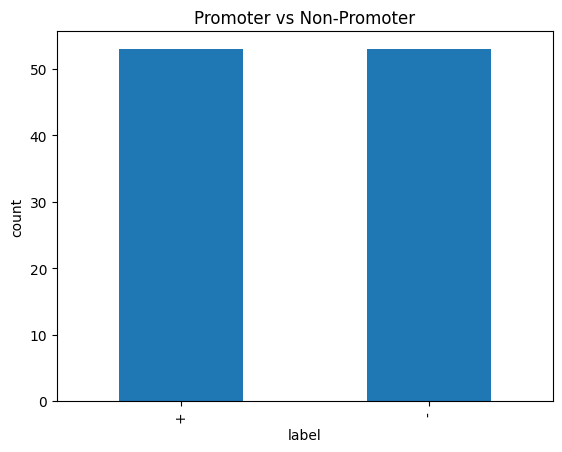

a    1575
c    1385
g    1370
t    1712
Name: count, dtype: int64


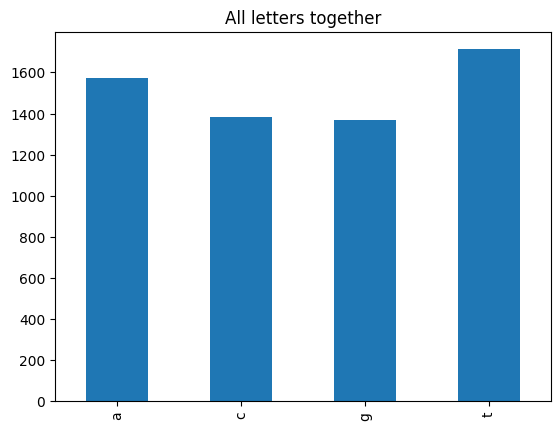

label        0
sequence     0
label_num    0
length       0
dtype: int64


In [5]:
print(df["label"].value_counts())
df["label"].value_counts().plot(kind="bar", title="Promoter vs Non-Promoter")
plt.ylabel("count")
plt.show()

overall = pd.Series(list("".join(df["sequence"]))).value_counts().sort_index()
print(overall)
overall.plot(kind="bar", title="All letters together")
plt.show()

print(df.isnull().sum())

# 1.2 EDA: Looking at Each Position

We have 57 positions in total. Is every position random, or do some tend to be a certain letter?

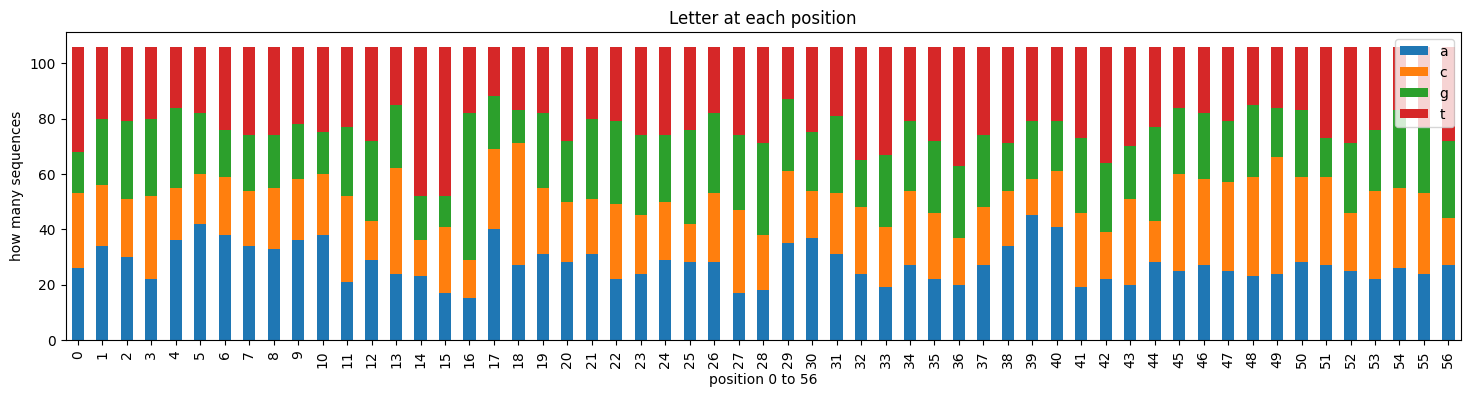

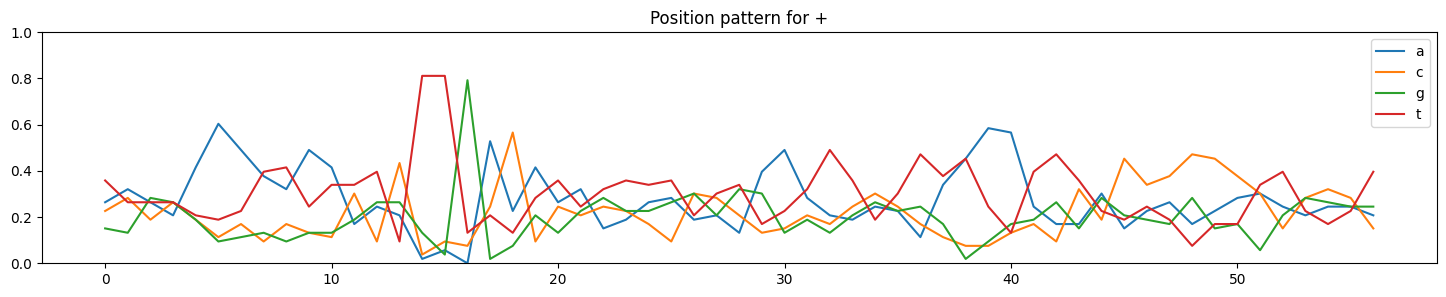

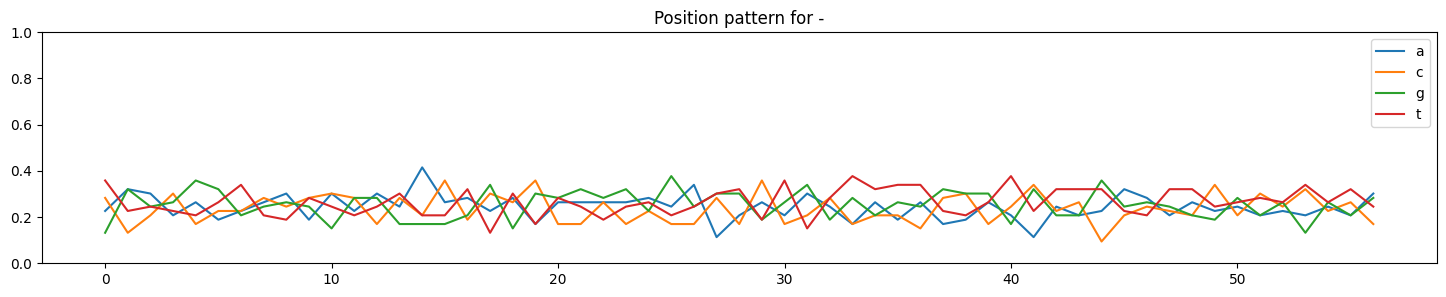

In [6]:
counts = {b: [] for b in "acgt"}
positions = range(57)

for pos in positions:
  col = df["sequence"].str[pos].value_counts()
  for b in "acgt":
    counts[b].append(col.get(b, 0))

pos_df = pd.DataFrame(counts, index=positions)
pos_df.plot(kind="bar", stacked=True, figsize=(18, 4), title="Letter at each position")
plt.xlabel("position 0 to 56")
plt.ylabel("how many sequences")
plt.show()

for lab in ["+", "-"]:
  sub = df[df["label"] == lab]
  c2 = {b: [] for b in "acgt"}

  for pos in positions:
    col = sub["sequence"].str[pos].value_counts()
    for b in "acgt":
      c2[b].append(col.get(b, 0) / len(sub))

  pd.DataFrame(c2).plot(title=f"Position pattern for {lab}", figsize=(18, 3))
  plt.ylim(0, 1)
  plt.show()

# 2.1 Turning Letters into Numbers: Position Approach

Models can't read ACGT. Each 57-letter string needs to be converted to numbers.

There are multiple ways to do this. One simple way is to make 4 columns for each position (e.g. `pos0_A`, `pos0_C`, `pos0_G`, `pos0_T`), resulting in 106x57 letters turning into 106x228 flags. The model can learn stuff like "T at position 40 is important", matching the spike observable from the `+` graph.

In [7]:
seq_split = df["sequence"].apply(lambda s: pd.Series(list(s)))
seq_split.columns = [f"pos{i}" for i in range(57)]

from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_onehot = enc.fit_transform(seq_split)

print(X_onehot.shape)
print(enc.get_feature_names_out()[:8])
print(df["sequence"].iloc[0][:10], "->", X_onehot[0, :8])

(106, 228)
['pos0_a' 'pos0_c' 'pos0_g' 'pos0_t' 'pos1_a' 'pos1_c' 'pos1_g' 'pos1_t']
tactagcaat -> [0. 0. 0. 1. 1. 0. 0. 0.]


# 2.2 Turning Letters into Numbers: Counting Approach

As an alternative, we could simply count how many times each pair appears. Pairs: `AA`, `AC`, `AG`, `AT`... 16 of them. Hence, this approach will yield 106x16 numbers which is much less than the first approach.

If this approach outperforms the first one, then it would imply that position doesn't matter. We expect it to do worse.